In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from idlpy import *
import geopandas as gpd
import cartopy.crs as ccrs
crs = ccrs.Mercator()


IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 783885


In [3]:
# load streamflow data
dfs = []
for s in ['summer','autumn','winter','spring']:
    obs_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/obs/streamflow/streamflow_obs_'+s+'_gaussian.csv')
    obs_df = obs_df.set_index('date').drop('36001',axis=1)
    
    dfs.append(obs_df)
    
obs_df = pd.concat(dfs)
obs_df = obs_df.sort_index()


# populate start year dictionary
start_year_dict = {}
for site in obs_df:
    start_year_dict[site] = [float(obs_df[site].first_valid_index().split('-')[0])]
    
start_years = pd.DataFrame(start_year_dict)


# load catchment shape data
fp = '/nesi/project/niwa00015/queenle/data/arcgis/'
file = 'NESTCAT_v2_NZTM.shp'
catchment_data = gpd.read_file(fp+file)
catchment_data = catchment_data.to_crs("EPSG:4326")
catchment_data = catchment_data.loc[catchment_data['SITE'].isin(obs_df.columns)]
catchment_data.index = catchment_data['SITE']

crs_proj4 = ccrs.Mercator().proj4_init
catchments_df_ae = catchment_data.to_crs(crs_proj4)


1951
getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
(659,)
(659,)
(659,)
(2, 659)
(100, 659)
(100, 659)



getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
(668,)
(668,)
(668,)
(2, 668)
(100, 668)
(100, 668)



getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
(661,)
(661,)
(661,)
(2, 661)
(100, 661)
(100, 661)



getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
(666,)
(666,)
(666,)
(2, 666)
(100, 666)
(100, 666)





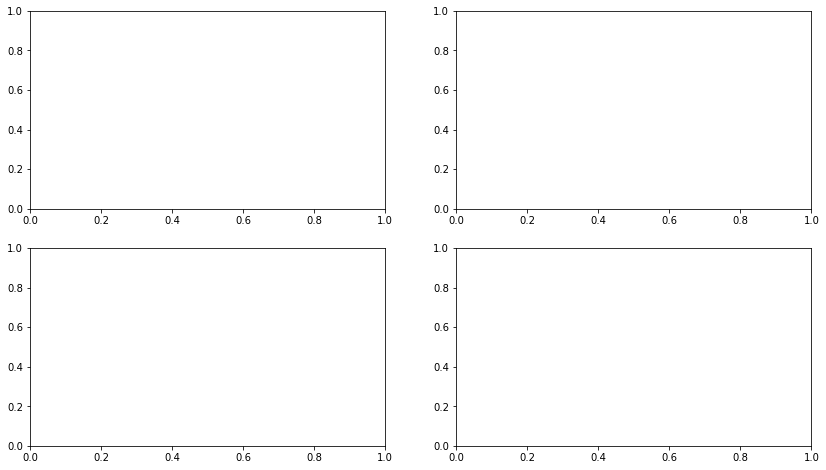

1955
getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
(808,)
(808,)
(808,)
(2, 808)
(100, 808)
(100, 808)



getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
(817,)
(817,)
(817,)
(2, 817)
(100, 817)
(100, 817)



getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
(809,)
(809,)
(809,)
(2, 809)
(100, 809)
(100, 809)



getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
(815,)
(815,)
(815,)
(2, 815)
(100, 815)
(100, 815)





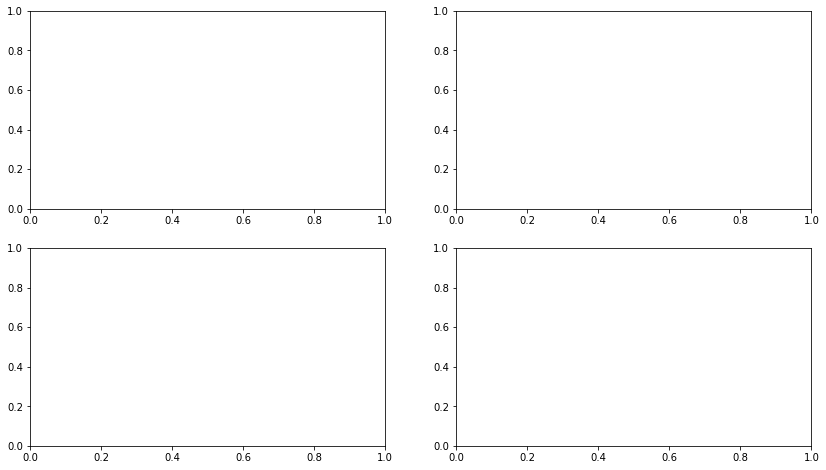

1960
getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
(1432,)
(1432,)
(1432,)
(2, 1432)
(100, 1432)
(100, 1432)



getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
(1445,)
(1445,)
(1445,)
(2, 1445)
(100, 1445)
(100, 1445)



getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
(1435,)
(1435,)
(1435,)
(2, 1435)
(100, 1435)
(100, 1435)



getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
(1431,)
(1431,)
(1431,)
(2, 1431)
(100, 1431)
(100, 1431)





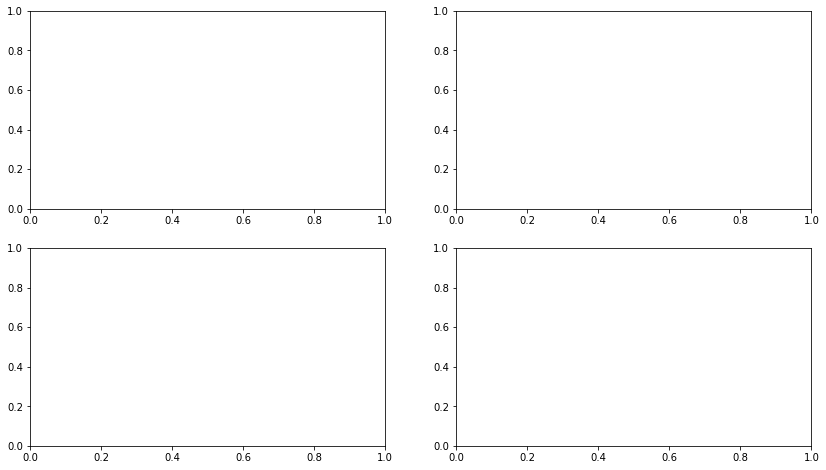

1965
getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
(2168,)
(2168,)
(2168,)
(2, 2168)
(100, 2168)
(100, 2168)



getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
(2175,)
(2175,)
(2175,)
(2, 2175)
(100, 2175)
(100, 2175)



getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
(2155,)
(2155,)
(2155,)
(2, 2155)
(100, 2155)
(100, 2155)



getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
(2168,)
(2168,)
(2168,)
(2, 2168)
(100, 2168)
(100, 2168)





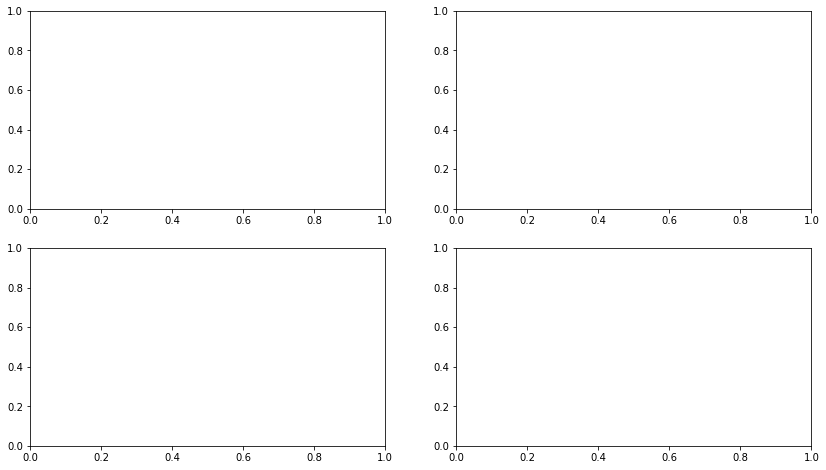

1970
getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
(2459,)
(2459,)
(2459,)
(2, 2459)
(100, 2459)
(100, 2459)



getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
(2475,)
(2475,)
(2475,)
(2, 2475)
(100, 2475)
(100, 2475)



getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
(2457,)
(2457,)
(2457,)
(2, 2457)
(100, 2457)
(100, 2457)



getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
(2468,)
(2468,)
(2468,)
(2, 2468)
(100, 2468)
(100, 2468)





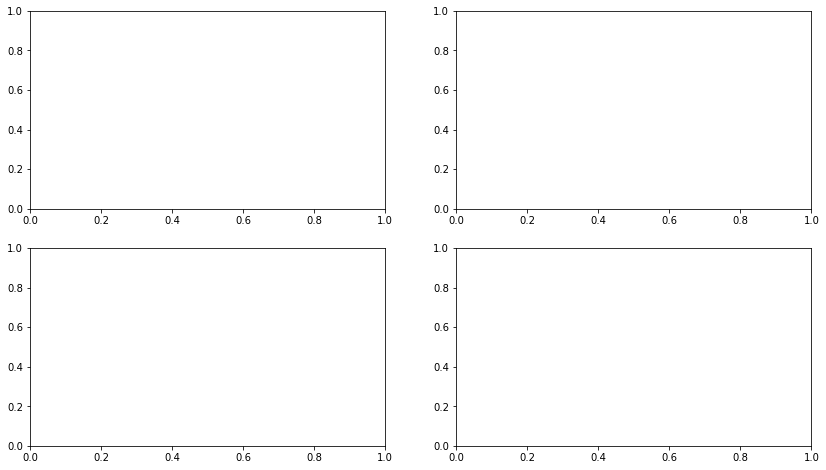

In [19]:
'''
MAIN function for performing optimal fingerprinting
'''

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 16,
        }

end = 2019
trunc = np.array([i for i in range(3,98)])

for start in [1951,1955,1960,1965,1970]:
        
    print(start)
    
    # determine active stations
    sites = start_years[start_years<=start].dropna(axis=1).columns
    '''    
    # plot active catchments
    fig, ax = plt.subplots(figsize=(12,10),subplot_kw={'projection': crs})
    catchments_df_ae.loc[catchments_df_ae['SITE'].isin(sites)].plot(ax=ax,color='lightblue',edgecolor='black',linewidth=0.2,alpha=0.7)
    ax.set_xlim([1.85e7,1.99e7])
    ax.set_ylim([-6000000,-4000000])
    ax.coastlines()
    plt.show()
    plt.close()
    '''
    # do fingerprinting with select catchments
    axs = axs.flatten() 
    for i,season in enumerate(['summer','autumn','winter','spring']):

        scan_beta_est,trunc = run_fingerprinting(sites,season,start,end)

        save_result(scan_beta_est,trunc,season,start,end)
        
    plt.show()
    plt.close()


In [14]:

def run_fingerprinting(sites,season,start,end):
    
    IDL.retall

    data_obs,all_ens_mean,noise_all,nat_ens_mean,noise_nat = get_all_data(sites,season,start,end)

    data_scen = np.array([all_ens_mean,nat_ens_mean])
    data_noise_1 = np.concatenate((noise_all[:50],noise_nat[:50]))
    data_noise_2 = np.concatenate((noise_all[50:],noise_nat[50:]))

    print('got arrays')

    

    IDL.data_obs = data_obs
    IDL.data_scen = data_scen
    IDL.data_noise_1 = data_noise_1
    IDL.data_noise_2 = data_noise_2
    IDL.trunc = trunc
    IDL.scan_beta_est = []
    IDL.scan_p_resid = []


    print('running gendetec')
    IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
            data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, scan_beta_est=scan_beta_est,\
            scan_p_resid=scan_p_resid")

    scan_beta_est = IDL.scan_beta_est
    scan_p_resid = IDL.scan_p_resid
    
    
    print(all_ens_mean.shape)
    print(nat_ens_mean.shape)
    print(data_obs.shape)
    print(data_scen.shape)
    print(data_noise_1.shape)
    print(data_noise_2.shape)
    print('\n\n')
    
    return(scan_beta_est,trunc)
    #save_result(scan_beta_est,trunc,season,start,end)
    

In [5]:
def get_all_data(sites, season, start, end):
    
    print('getting obs')
    data_obs,missing_indices = get_obs_data(sites,season,start,end)
    
    print('getting ALL mean and noise')
    all_ens_mean,noise_all = get_mean_and_noise(sites,missing_indices,'HPB',season,start,end)
    
    print('getting NAT mean and noise')
    nat_ens_mean,noise_nat = get_mean_and_noise(sites,missing_indices,'HPB_NAT',season,start,end)

    return(data_obs,all_ens_mean,noise_all,nat_ens_mean,noise_nat)

In [12]:
def get_obs_data(sites,season,start,end):
    
    obs_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/obs/streamflow/streamflow_obs_'+season+'_gaussian.csv')
    obs_df = obs_df.set_index('date').drop('36001',axis=1)
    obs_df = obs_df[str(start):str(end+1)]
    obs_df = obs_df[sites]
            
    obs_array = obs_df.values.flatten()
    
    # find indices of nan values
    missing_indices = np.argwhere(np.isnan(obs_array))
    
    # remove nan values
    obs_array = np.delete(obs_array,missing_indices)
    
    return(obs_array,missing_indices)

def get_noise(sites,missing_indices,scen,season,mean_array,start,end):
    
    noise = []
    for ens_mem in range(1,101):
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)
                
        mem_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/ROF/seasonal/station_resolution/ROF_d4PDF_'+scen+'_m'+number+'_gaussian_'+season+'_1951-2021.csv')
        mem_df = mem_df.set_index('time').drop(['Unnamed: 0','36001'],axis=1)
        mem_df = mem_df[str(start):str(end+1)]
        mem_df = mem_df[sites]
        mem_array = mem_df.values.flatten()
                
        # remove elements where observations were missing
        mem_array = np.delete(mem_array,missing_indices)
        
        diff_array = mem_array - mean_array
        
        noise.append(diff_array)
        
    return(noise)

def get_mean_and_noise(sites,missing_indices,scen,season,start,end):
    
    mean_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/ROF/seasonal/station_resolution/ROF_d4PDF_'+scen+'_ensMean_gaussian_'+season+'_1951-2021.csv')
    mean_df = mean_df.set_index('time').drop('36001',axis=1)
    mean_df = mean_df[str(start):str(end+1)]
    mean_df = mean_df[sites]
    mean_array = mean_df.values.flatten()
    
    # remove elements where observations were missing
    mean_array = np.delete(mean_array,missing_indices)
        
    noise = get_noise(sites,missing_indices,scen,season,mean_array,start,end)
    
    return((mean_array, np.array(noise)))


In [18]:
def save_result(scan_beta_est,trunc,season,start,end):

    df_dict = {'Truncation':trunc,'ant_best':[],'ant_lower':[],'ant_upper':[],'nat_best':[],'nat_lower':[],'nat_upper':[]}
    
    for j in range(len(scan_beta_est)):

        beta_est = scan_beta_est[j]

        df_dict['ant_best'].append(beta_est[0][0])
        df_dict['ant_lower'].append(beta_est[1][0])
        df_dict['ant_upper'].append(beta_est[2][0])
        
        df_dict['nat_best'].append(beta_est[0][1])
        df_dict['nat_lower'].append(beta_est[1][1])
        df_dict['nat_upper'].append(beta_est[2][1])
        
    df = pd.DataFrame.from_dict(df_dict)
    
    df.to_csv('/home/queenle/hydro_attribution/result_files/d4PDF_ROF_obs_'+season+'_'+str(start)+'_'+str(end)+'.csv')
    